加载用户特征数据: (795, 59)
可用特征: ['Total_Sales', 'Total_Orders', 'Avg_Order_Value', 'Customer_Lifetime_Days', 'Purchase_Frequency', 'Avg_Browsing_Time', 'Profit_Margin', 'Days_Since_Last_Purchase', 'Total_Engagement_Score', 'Unique_Products_Purchased']


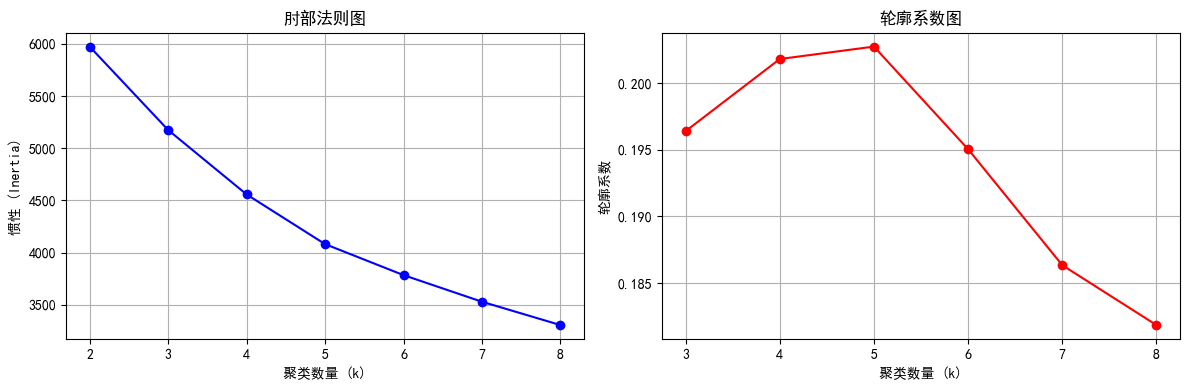

建议的聚类数量: 2

每个聚类的用户分布:
聚类 0: 425 用户 (53.5%)
聚类 1: 370 用户 (46.5%)

各聚类关键特征的平均值:

特征差异百分比（相对于整体平均）:

聚类 0:
  Total_Sales: -15.8%
  Total_Orders: -15.3%
  Avg_Order_Value: -0.5%
  Customer_Lifetime_Days: -0.6%
  Purchase_Frequency: -14.7%

聚类 1:
  Total_Sales: +18.1%
  Total_Orders: +17.5%
  Avg_Order_Value: +0.6%
  Customer_Lifetime_Days: +0.7%
  Purchase_Frequency: +16.8%

用户画像分析结果

聚类 0:
  用户数: 425 (53.5%)
  平均总销售额: $8,498.89
  平均订单数: 54.7
  平均订单价值: $155.58
  画像特征: 低Total_Orders，低Total_Sales，低Purchase_Frequency

聚类 1:
  用户数: 370 (46.5%)
  平均总销售额: $11,921.81
  平均订单数: 75.8
  平均订单价值: $157.28
  画像特征: 高Total_Orders，高Total_Sales，高Purchase_Frequency，高Total_Engagement_Score，高Unique_Products_Purchased


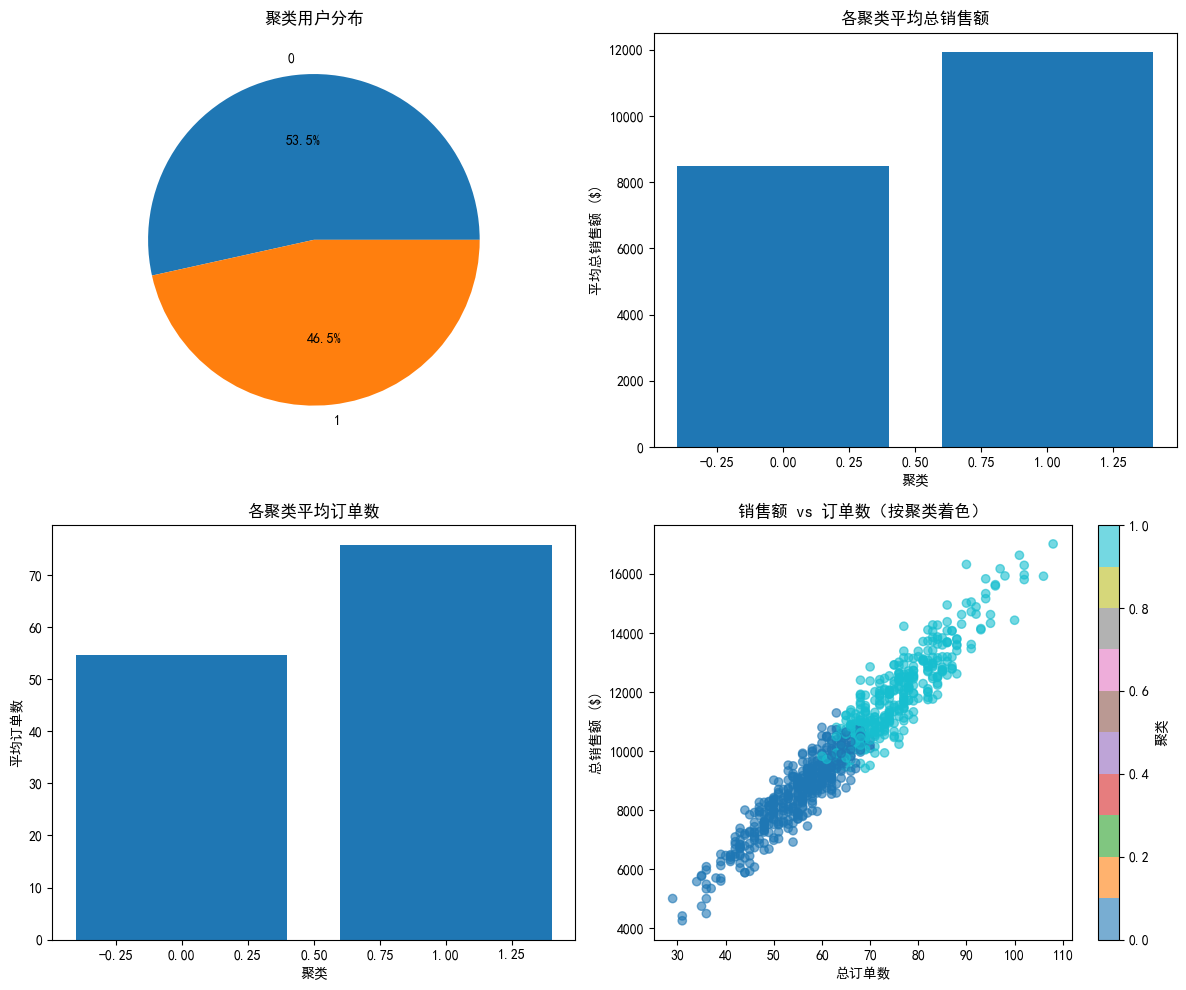


聚类结果已保存到: customer_clusters_simple.csv

业务建议

聚类 0 建议:

聚类 1 建议:
  • VIP客户：提供专属客服和优先服务
  • 高频客户：推荐忠诚度计划和定期优惠


In [3]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
import seaborn as sns

# 1. 加载用户特征数据（假设已经完成特征工程）
# 如果你已经保存了特征工程后的数据，可以直接加载
try:
    customer_features = pd.read_csv('customer_features_complete.csv')
    print(f"加载用户特征数据: {customer_features.shape}")
except:
    print("请先运行特征工程代码生成用户特征数据")
    # 这里假设你已经有了customer_prediction，如果没有，需要先运行特征工程
    # 我们先创建一个简化的版本
    pass

# 2. 选择最关键的10个特征进行聚类（简化计算）
key_clustering_features = [
    'Total_Sales',          # 总销售额
    'Total_Orders',         # 总订单数
    'Avg_Order_Value',      # 平均订单价值
    'Customer_Lifetime_Days', # 客户生命周期
    'Purchase_Frequency',   # 购买频率
    'Avg_Browsing_Time',    # 平均浏览时间
    'Profit_Margin',        # 利润率
    'Days_Since_Last_Purchase', # 最近购买天数
    'Total_Engagement_Score', # 总互动分
    'Unique_Products_Purchased' # 购买产品种类
]

# 检查哪些特征存在
available_features = [col for col in key_clustering_features 
                     if col in customer_features.columns]
print(f"可用特征: {available_features}")

# 3. 准备聚类数据
X = customer_features[available_features].copy()

# 处理缺失值
X = X.fillna(X.median())

# 标准化数据
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 4. 快速确定最佳聚类数量（使用简化的方法）
# 尝试2-8个聚类
k_range = range(2, 9)
inertia_values = []
silhouette_values = []

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    
    inertia_values.append(kmeans.inertia_)
    
    # 计算轮廓系数（只在k>1时）
    if k > 1:
        silhouette_values.append(silhouette_score(X_scaled, kmeans.labels_))
    else:
        silhouette_values.append(0)

plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False  # 解决负号显示问题
# 快速可视化
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# 肘部法则
axes[0].plot(k_range, inertia_values, 'bo-')
axes[0].set_xlabel('聚类数量 (k)')
axes[0].set_ylabel('惯性 (Inertia)')
axes[0].set_title('肘部法则图')
axes[0].grid(True)

# 轮廓系数
axes[1].plot(k_range[1:], silhouette_values[1:], 'ro-')
axes[1].set_xlabel('聚类数量 (k)')
axes[1].set_ylabel('轮廓系数')
axes[1].set_title('轮廓系数图')
axes[1].grid(True)

plt.tight_layout()
plt.show()

# 5. 选择最佳k值（使用轮廓系数）
best_k = k_range[np.argmax(silhouette_values)]
print(f"建议的聚类数量: {best_k}")

# 6. 执行K-means聚类
kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_scaled)

# 将聚类结果添加到原始数据
customer_features['Cluster'] = clusters

# 7. 快速分析每个聚类
print(f"\n每个聚类的用户分布:")
cluster_counts = customer_features['Cluster'].value_counts().sort_index()
for cluster_id, count in cluster_counts.items():
    percentage = count / len(customer_features) * 100
    print(f"聚类 {cluster_id}: {count} 用户 ({percentage:.1f}%)")

# 8. 分析聚类特征
print(f"\n各聚类关键特征的平均值:")
cluster_means = customer_features.groupby('Cluster')[available_features].mean()

# 计算相对于整体平均的差异（标准化）
overall_means = customer_features[available_features].mean()
cluster_differences = cluster_means.subtract(overall_means).divide(overall_means) * 100

print("\n特征差异百分比（相对于整体平均）:")
for cluster_id in cluster_differences.index:
    print(f"\n聚类 {cluster_id}:")
    for feature in available_features[:5]:  # 只显示前5个特征
        diff = cluster_differences.loc[cluster_id, feature]
        print(f"  {feature}: {diff:+.1f}%")

# 9. 创建简单的用户画像
def create_simple_profiles(customer_data, clusters_array, n_features=5):
    """创建简化的用户画像"""
    
    # 将聚类标签添加到数据副本中
    customer_data = customer_data.copy()
    customer_data['Cluster'] = clusters_array
    
    profiles = {}
    
    # 使用np.unique获取唯一的聚类标签
    unique_clusters = np.unique(clusters_array)
    
    for cluster_id in sorted(unique_clusters):
        cluster_data = customer_data[customer_data['Cluster'] == cluster_id]
        
        # 计算每个特征的z-score
        feature_scores = {}
        for feature in available_features:
            mean = customer_data[feature].mean()
            std = customer_data[feature].std()
            cluster_mean = cluster_data[feature].mean()
            if std > 0:  # 避免除以0
                z_score = (cluster_mean - mean) / std
            else:
                z_score = 0
            feature_scores[feature] = z_score
        
        # 找出最重要的特征（绝对值最大的z-score）
        sorted_features = sorted(feature_scores.items(), key=lambda x: abs(x[1]), reverse=True)
        
        # 创建画像描述
        profile_desc = []
        for feature, z_score in sorted_features[:n_features]:
            if abs(z_score) > 0.5:  # 只显示显著特征
                if z_score > 0.5:
                    profile_desc.append(f"高{feature}")
                elif z_score < -0.5:
                    profile_desc.append(f"低{feature}")
        
        # 基本统计
        profiles[cluster_id] = {
            'size': len(cluster_data),
            'percentage': len(cluster_data) / len(customer_data) * 100,
            'avg_sales': cluster_data['Total_Sales'].mean(),
            'avg_orders': cluster_data['Total_Orders'].mean(),
            'avg_order_value': cluster_data['Avg_Order_Value'].mean(),
            'profile': "，".join(profile_desc) if profile_desc else "无明显特征"
        }
    
    return profiles

# 生成画像
profiles = create_simple_profiles(customer_features, clusters)

print(f"\n{'='*60}")
print("用户画像分析结果")
print(f"{'='*60}")

for cluster_id, profile in profiles.items():
    print(f"\n聚类 {cluster_id}:")
    print(f"  用户数: {profile['size']} ({profile['percentage']:.1f}%)")
    print(f"  平均总销售额: ${profile['avg_sales']:,.2f}")
    print(f"  平均订单数: {profile['avg_orders']:.1f}")
    print(f"  平均订单价值: ${profile['avg_order_value']:,.2f}")
    print(f"  画像特征: {profile['profile']}")

# 10. 简单的可视化
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# 聚类分布饼图
cluster_counts = customer_features['Cluster'].value_counts().sort_index()
axes[0, 0].pie(cluster_counts.values, labels=cluster_counts.index, autopct='%1.1f%%')
axes[0, 0].set_title('聚类用户分布')

# 销售额对比条形图
sales_by_cluster = customer_features.groupby('Cluster')['Total_Sales'].mean()
axes[0, 1].bar(sales_by_cluster.index, sales_by_cluster.values)
axes[0, 1].set_xlabel('聚类')
axes[0, 1].set_ylabel('平均总销售额 ($)')
axes[0, 1].set_title('各聚类平均总销售额')

# 订单数对比条形图
orders_by_cluster = customer_features.groupby('Cluster')['Total_Orders'].mean()
axes[1, 0].bar(orders_by_cluster.index, orders_by_cluster.values)
axes[1, 0].set_xlabel('聚类')
axes[1, 0].set_ylabel('平均订单数')
axes[1, 0].set_title('各聚类平均订单数')

# 散点图：销售额 vs 订单数
scatter = axes[1, 1].scatter(
    customer_features['Total_Orders'], 
    customer_features['Total_Sales'], 
    c=customer_features['Cluster'], 
    cmap='tab10', 
    alpha=0.6
)
axes[1, 1].set_xlabel('总订单数')
axes[1, 1].set_ylabel('总销售额 ($)')
axes[1, 1].set_title('销售额 vs 订单数（按聚类着色）')
plt.colorbar(scatter, ax=axes[1, 1], label='聚类')

plt.tight_layout()
plt.show()

# 11. 保存结果
customer_features.to_csv('customer_clusters_simple.csv', index=False)
print(f"\n聚类结果已保存到: customer_clusters_simple.csv")

# 12. 生成业务建议
print(f"\n{'='*60}")
print("业务建议")
print(f"{'='*60}")

for cluster_id, profile in profiles.items():
    print(f"\n聚类 {cluster_id} 建议:")
    
    if '高Total_Sales' in profile['profile']:
        print("  • VIP客户：提供专属客服和优先服务")
    
    if '高Purchase_Frequency' in profile['profile']:
        print("  • 高频客户：推荐忠诚度计划和定期优惠")
    
    if '高Avg_Browsing_Time' in profile['profile']:
        print("  • 深度浏览者：提供详细产品信息和比较工具")
    
    if '低Days_Since_Last_Purchase' in profile['profile']:
        print("  • 近期活跃客户：进行交叉销售和向上销售")
    
    if '高Days_Since_Last_Purchase' in profile['profile']:
        print("  • 流失风险客户：发送再营销邮件和特别优惠")
    
    # 基于利润率建议
    if '高Profit_Margin' in profile['profile']:
        print("  • 高利润客户：保持良好关系，提供优质服务")
    
    if '低Profit_Margin' in profile['profile']:
        print("  • 低利润客户：优化成本或调整定价策略")